# The baseline ladder

Before any LLM, establish what cheap models achieve. Every rung uses the same `Report`, so the
fine-tuned model later is directly comparable.

Rungs: always-guess-the-average, metadata-only linear regression, TF-IDF + Ridge, and LSA + random
forest.

In [1]:
from pricer.baselines import constant, lsa_forest, metadata_only, tfidf
from pricer.evaluator import evaluate, leaderboard
from pricer.items import Wine

train, val, test = Wine.load_local()
print(f"train={len(train):,} val={len(val):,} test={len(test):,}")

train=79,359 val=2,000 test=2,000


### Rung 0: the geometric mean

Any model that cannot beat this is broken. Note the negative R2 -- squared error in dollars is
dominated by the expensive tail, which is exactly why RMSLE is the metric to watch.

Constant $30:   0%|          | 0/2000 [00:00<?, ?it/s]

Constant $30: MAE $23.96 | RMSLE 0.749 | R2 -7.7% | hits 29.6%


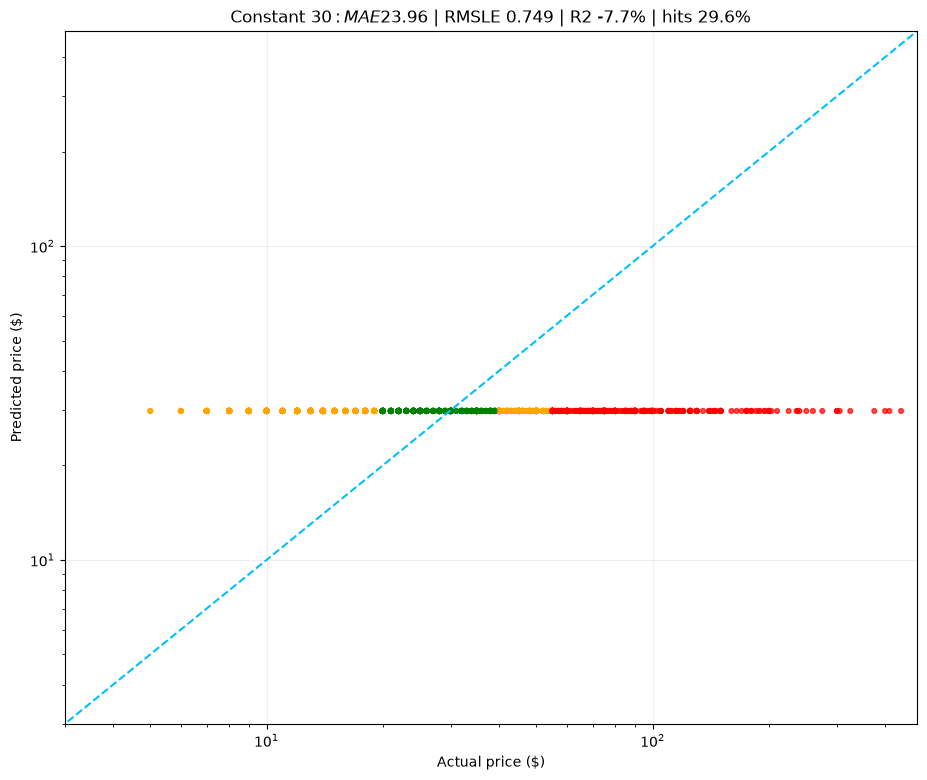

In [2]:
evaluate(constant(train), test)

### Rung 1: metadata only, no tasting note

Country, province, variety, vintage, note length.

Metadata + Linear Regression:   0%|          | 0/2000 [00:00<?, ?it/s]

Metadata + Linear Regression: MAE $17.40 | RMSLE 0.532 | R2 29.2% | hits 52.8%


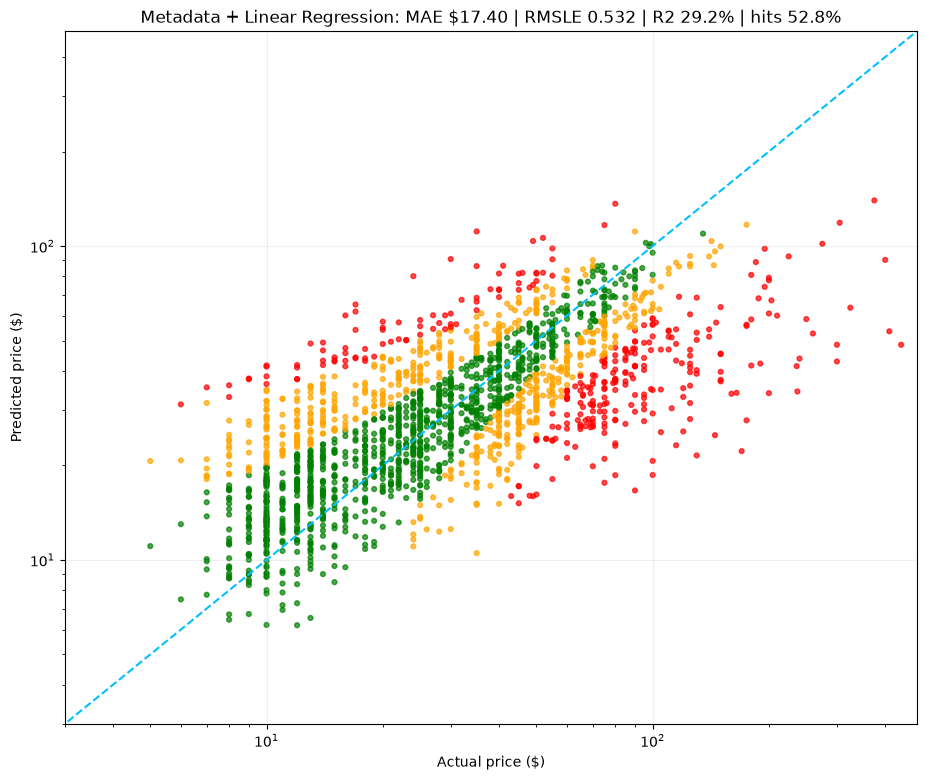

In [3]:
evaluate(metadata_only(train), test)

### Rung 2: the tasting note as bag-of-words

Tf-Idf + Ridge:   0%|          | 0/2000 [00:00<?, ?it/s]

Tf-Idf + Ridge: MAE $15.31 | RMSLE 0.454 | R2 44.4% | hits 58.9%


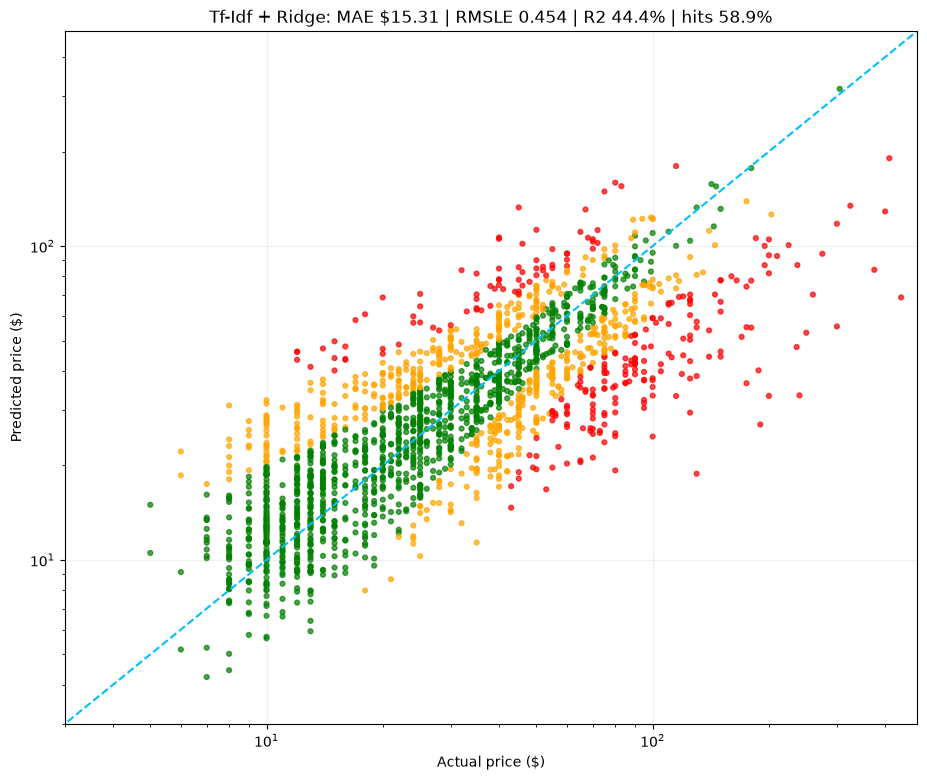

In [4]:
evaluate(tfidf(train), test)

### Rung 3: dense text features into a random forest

Lsa + Random Forest:   0%|          | 0/2000 [00:00<?, ?it/s]

Lsa + Random Forest: MAE $16.57 | RMSLE 0.505 | R2 34.1% | hits 55.1%


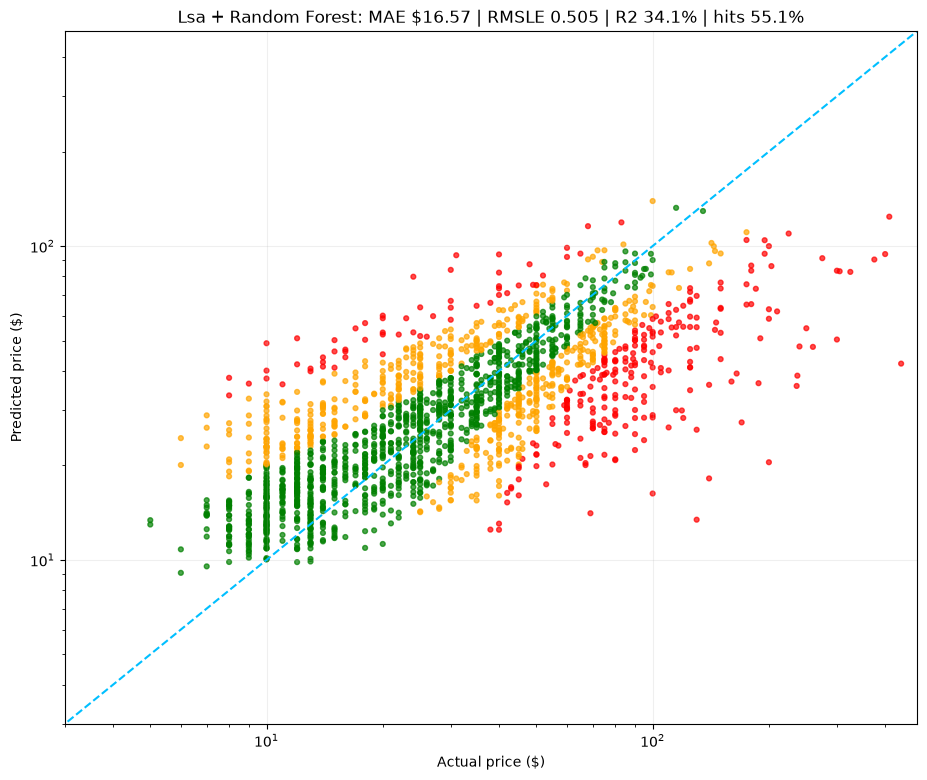

In [5]:
evaluate(lsa_forest(train), test)

In [6]:
leaderboard()

model                                    MAE    RMSLE      R2    hits      n
Tf-Idf + Ridge                        15.31    0.454   44.4%   58.9%  2,000
Lsa + Random Forest                   16.57    0.505   34.1%   55.1%  2,000
Classical (note only)                 16.38    0.518   39.0%   57.0%    100
Metadata + Linear Regression          17.40    0.532   29.2%   52.8%  2,000
Neighbours (k=8, retrieval only)      18.49    0.554   32.4%   49.0%    100
Frontier (RAG + LLM)                  20.74    0.639   29.8%   46.0%    100
Constant $30                          23.96    0.749   -7.7%   29.6%  2,000


### Which words cost money?

Ridge coefficients on the word features, which double as a sanity check that the model is reading
tasting vocabulary rather than picking up on a scrape artefact.

In [7]:
import numpy as np

model = tfidf(train)
pipeline = model.pipeline
features = pipeline.named_steps["features"]
names = features.get_feature_names_out()
weights = pipeline.named_steps["model"].coef_
order = np.argsort(weights)
print("cheap:")
for index in order[:15]:
    print(f"  {names[index].split('__')[-1]:<24}{weights[index]:+.3f}")
print("expensive:")
for index in order[-15:][::-1]:
    print(f"  {names[index].split('__')[-1]:<24}{weights[index]:+.3f}")

cheap:
  value                   -2.665
  price                   -2.065
  bargain                 -1.822
  inexpensive             -1.815
  affordable              -1.571
  best buy                -1.535
  buy                     -1.450
  chianti                 -1.391
  ripasso                 -1.326
  more expensive          -1.236
  kabinett                -1.234
  000 cases               -1.049
  lodi                    -1.048
  priced                  -1.039
  médoc                   -1.037
expensive:
  gaja                    +2.001
  rancio                  +1.653
  tba                     +1.561
  condrieu                +1.558
  drink through           +1.511
  2030                    +1.473
  amarone                 +1.454
  cases made              +1.430
  from 2012               +1.378
  2024                    +1.364
  2025                    +1.362
  2022                    +1.338
  beerenauslese           +1.337
  2032                    +1.306
  priorat                

### Experiments worth running here

- Re-curate with `cap=20_000` and see whether the extra cheap wines help or just re-teach the prior.
- Add `points` to the composed text (`pricer.parser.compose`) and measure the jump. That gap is the
  value of the critic score, and a lower bound on how much a model can learn from the note alone.
- Predict `points` instead of price -- same harness, a much less skewed target.
- Swap Ridge for gradient boosting on the LSA features.